# Modelo preditivo de ações

1. Importar bibliotecas

In [1]:

pip install neuralprophet yfinance matplotlib scikit-learn pandas torch

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 12.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 12.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 14.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 14.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 15.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/

In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import torch as torch

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from neuralprophet import NeuralProphet

Matplotlib is building the font cache; this may take a moment.
/Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


2. Download dos dados

In [3]:
# Informações de entrada

ticker = "PETR4.SA"
initial = "2005-01-01"
final = "2020-01-01"

# Dados históricos

data = yf.download(ticker, start=initial, end=final, multi_level_index=False)

# Visualização dos dados
data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2005-01-03,2.103572,2.186196,2.103348,2.177264,30044800
2005-01-04,2.078561,2.134834,2.076774,2.121213,37667200
2005-01-05,2.070523,2.103126,2.049978,2.083475,30873600
2005-01-06,2.076775,2.087941,2.052211,2.081688,28224000
2005-01-07,2.085931,2.105806,2.065833,2.081018,25980800
...,...,...,...,...,...
2019-12-20,8.571090,8.667394,8.503110,8.667394,93064900
2019-12-23,8.639072,8.639072,8.505946,8.551266,21970200
2019-12-26,8.755203,8.760868,8.639072,8.664564,24810500


3. Tratamento dos dados
- Converter as datas em datetimes
- Formatar os dados para input no neuralprohet
- Formatar coluna ds e y

In [4]:
data.index = pd.to_datetime(data.index)
data = data[["Close"]].reset_index()
data.columns = ["ds", "y"]
data

,ds,y
0,2005-01-03,2.103572
1,2005-01-04,2.078561
2,2005-01-05,2.070523
3,2005-01-06,2.076775
4,2005-01-07,2.085931
...,...,...
3724,2019-12-20,8.571090
3725,2019-12-23,8.639072
3726,2019-12-26,8.755203
3727,2019-12-27,8.764374


4. Treinando o modelo

In [5]:
modelo = NeuralProphet(learning_rate=0.01)
metrics = modelo.fit(data)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtyp

Epoch 1:   1%|▏         | 1/80 [00:00<00:00, 2041.02it/s]

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 17. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



Training: |          | 0/? [00:24<?, ?it/s, v_num=0, train_loss=0.0165, reg_loss=0.000, MAE=0.627, RMSE=0.852, Loss=0.0164, RegLoss=0.000]


4. Criar dataframe com previsoes futuras
- Criar dataframe


In [6]:
dados_futuros = modelo.make_future_dataframe(data, periods=900)

previsoes_futuras = modelo.predict(dados_futuros)

previsoes_historicas = modelo.predict(data)

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.192% of the data.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future 

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 57.18it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.192% of the data.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/df_utils


Predicting DataLoader 0: 100%|██████████| 4/4 [00:00<00:00, 88.28it/s]


INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [7]:
previsoes_historicas

,ds,y,yhat1,trend,season_yearly,season_weekly
0,2005-01-03,2.103572,2.968247,0.536881,-0.081422,2.512788
1,2005-01-04,2.078561,2.962062,0.538293,-0.080968,2.504737
2,2005-01-05,2.070523,2.968591,0.539705,-0.080551,2.509437
3,2005-01-06,2.076775,2.972458,0.541117,-0.080187,2.511528
4,2005-01-07,2.085931,2.956782,0.542528,-0.079883,2.494137
...,...,...,...,...,...,...
3724,2019-12-20,8.571090,7.892326,5.468373,-0.077139,2.501092
3725,2019-12-23,8.639072,7.906527,5.480514,-0.081502,2.507515
3726,2019-12-26,8.755203,7.925285,5.492655,-0.083449,2.516079
3727,2019-12-27,8.764374,7.913601,5.496702,-0.083671,2.500570


In [8]:
previsoes_futuras

,ds,y,yhat1,trend,season_yearly,season_weekly
0,2019-12-31,None,7.935176,5.512890,-0.083071,2.505356
1,2020-01-01,None,7.941071,5.516940,-0.082676,2.506807
2,2020-01-02,None,7.953925,5.520986,-0.082237,2.515177
3,2020-01-03,None,7.943302,5.525034,-0.081775,2.500043
4,2020-01-06,None,7.958737,5.537176,-0.080459,2.502021
...,...,...,...,...,...,...
895,2023-06-06,None,12.989913,10.584006,-0.107182,2.513089
896,2023-06-07,None,12.973861,10.588052,-0.120308,2.506117
897,2023-06-08,None,12.973042,10.592101,-0.132804,2.513744
898,2023-06-09,None,12.957654,10.596148,-0.144645,2.506152


In [9]:
modelo.plot(previsoes_historicas)

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'fill': 'none',
              'line': {'color': 'rgba(45, 146, 255, 1.0)', 'width': 2},
              'mode': 'lines',
              'name': 'yhat1',
              'type': 'scatter',
              'x': array([datetime.datetime(2005, 1, 3, 0, 0),
                          datetime.datetime(2005, 1, 4, 0, 0),
                          datetime.datetime(2005, 1, 5, 0, 0), ...,
                          datetime.datetime(2019, 12, 26, 0, 0),
                          datetime.datetime(2019, 12, 27, 0, 0),
                          datetime.datetime(2019, 12, 30, 0, 0)], dtype=object),
              'y': {'bdata': ('wvc9QGuSPUBn/T1AwDw+QOo7PUBFLT' ... 'H8QPCN/EBFAv1A75v9QDk8/UCI7/1A'),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'size': 4},
              'mode': 'markers',
              'name': 'Actual',
              'type': 'scatter',
              'x': array([datetime.datetime(2005, 1, 3, 0, 0),
                          datetime.datetime(2005, 1, 4, 0, 0),
                          datetime.datetime(2005, 1, 5, 0, 0), ...,
                          datetime.datetime(2019, 12, 26, 0, 0),
                          datetime.datetime(2019, 12, 27, 0, 0),
                          datetime.datetime(2019, 12, 30, 0, 0)], dtype=object),
              'y': {'bdata': ('AAAAYB3UAEAAAABg5KAAQAAAACBukA' ... 'AAAKqCIUAAAAAAXIchQAAAAOBeVSFA'),
                    'dtype': 'f8'}}],
    'layout': {'autosize': True,
               'font': {'size': 10},
               'height': 420,
               'hovermode': 'x unified',
               'margin': {'b': 0, 'l': 0, 'pad': 0, 'r': 10, 't': 10},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'size': 12}},
               'width': 700,
               'xaxis': {'linewidth': 1.5,
                         'mirror': True,
                         'rangeselector': {'buttons': [{'count': 7, 'label': '1w', 'step': 'day', 'stepmode': 'backward'},
                                                       {'count': 1,
                                                        'label': '1m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 6,
                                                        'label': '6m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 1, 'label': '1y', 'step': 'year', 'stepmode': 'backward'},
                                                       {'step': 'all'}]},
                         'rangeslider': {'visible': True},
                         'showline': True,
                         'title': {'text': 'ds'},
                         'type': 'date'},
               'yaxis': {'linewidth': 1.5, 'mirror': True, 'showline': True, 'title': {'text': 'y'}}}
})

In [10]:
modelo.plot(previsoes_futuras)

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/plot_forecast_plotly.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fcst = fcst.fillna(value=np.nan)

WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'fill': 'none',
              'line': {'color': 'rgba(45, 146, 255, 1.0)', 'width': 2},
              'mode': 'lines',
              'name': 'yhat1',
              'type': 'scatter',
              'x': array([datetime.datetime(2019, 12, 31, 0, 0),
                          datetime.datetime(2020, 1, 1, 0, 0),
                          datetime.datetime(2020, 1, 2, 0, 0), ...,
                          datetime.datetime(2023, 6, 8, 0, 0),
                          datetime.datetime(2023, 6, 9, 0, 0),
                          datetime.datetime(2023, 6, 12, 0, 0)], dtype=object),
              'y': {'bdata': ('9uz9QEEd/kCNhv5Ahy/+QPqt/kDqBP' ... 'tPQa/WT0HvlE9BlJFPQY1ST0GD+U5B'),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'size': 4},
              'mode': 'markers',
              'name': 'Actual',
              'type': 'scatter',
              'x': array([datetime.datetime(2019, 12, 31, 0, 0),
                          datetime.datetime(2020, 1, 1, 0, 0),
                          datetime.datetime(2020, 1, 2, 0, 0), ...,
                          datetime.datetime(2023, 6, 8, 0, 0),
                          datetime.datetime(2023, 6, 9, 0, 0),
                          datetime.datetime(2023, 6, 12, 0, 0)], dtype=object),
              'y': {'bdata': ('AAAAAAAA+H8AAAAAAAD4fwAAAAAAAP' ... 'AAAAAA+H8AAAAAAAD4fwAAAAAAAPh/'),
                    'dtype': 'f8'}}],
    'layout': {'autosize': True,
               'font': {'size': 10},
               'height': 420,
               'hovermode': 'x unified',
               'margin': {'b': 0, 'l': 0, 'pad': 0, 'r': 10, 't': 10},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'size': 12}},
               'width': 700,
               'xaxis': {'linewidth': 1.5,
                         'mirror': True,
                         'rangeselector': {'buttons': [{'count': 7, 'label': '1w', 'step': 'day', 'stepmode': 'backward'},
                                                       {'count': 1,
                                                        'label': '1m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 6,
                                                        'label': '6m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 1, 'label': '1y', 'step': 'year', 'stepmode': 'backward'},
                                                       {'step': 'all'}]},
                         'rangeslider': {'visible': True},
                         'showline': True,
                         'title': {'text': 'ds'},
                         'type': 'date'},
               'yaxis': {'linewidth': 1.5, 'mirror': True, 'showline': True, 'title': {'text': 'y'}}}
})

In [11]:
modelo.plot_components(previsoes_historicas)

ERROR - (NP.plotly.plot_components) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - /Users/anaclaracaldeira/Library/Python/3.9/lib/python/site-packages/neuralprophet/plot_forecast_plotly.py:410: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst["ds"].dt.to_pydatetime()



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'line': {'color': '#2d92ff', 'width': 2},
              'mode': 'lines',
              'name': 'Trend',
              'showlegend': False,
              'type': 'scatter',
              'x': array([datetime.datetime(2005, 1, 3, 0, 0),
                          datetime.datetime(2005, 1, 4, 0, 0),
                          datetime.datetime(2005, 1, 5, 0, 0), ...,
                          datetime.datetime(2019, 12, 26, 0, 0),
                          datetime.datetime(2019, 12, 27, 0, 0),
                          datetime.datetime(2019, 12, 30, 0, 0)], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('DHEJP5LNCT8YKgo/noYKPyPjCj+0+A' ... 'uuQOr8rkBfYK9A1MOvQPzkr0B1SLBA'),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'line': {'color': '#2d92ff', 'width': 2},
              'mode': 'lines',
              'name': 'yearly seasonality',
              'showlegend': False,
              'type': 'scatter',
              'x': array([datetime.datetime(2005, 1, 3, 0, 0),
                          datetime.datetime(2005, 1, 4, 0, 0),
                          datetime.datetime(2005, 1, 5, 0, 0), ...,
                          datetime.datetime(2019, 12, 26, 0, 0),
                          datetime.datetime(2019, 12, 27, 0, 0),
                          datetime.datetime(2019, 12, 30, 0, 0)], dtype=object),
              'xaxis': 'x2',
              'y': {'bdata': ('oMCmvb/Spb3V96S94DikvbqZo7202a' ... 'eZvez6nb116qa9Gueqvctbq71uyKq9'),
                    'dtype': 'f4'},
              'yaxis': 'y2'},
             {'line': {'color': '#2d92ff', 'width': 2},
              'mode': 'lines',
              'name': 'weekly seasonality',
              'showlegend': False,
              'type': 'scatter',
              'x': array([datetime.datetime(2005, 1, 3, 0, 0),
                          datetime.datetime(2005, 1, 4, 0, 0),
                          datetime.datetime(2005, 1, 5, 0, 0), ...,
                          datetime.datetime(2019, 12, 26, 0, 0),
                          datetime.datetime(2019, 12, 27, 0, 0),
                          datetime.datetime(2019, 12, 30, 0, 0)], dtype=object),
              'xaxis': 'x3',
              'y': {'bdata': ('hNEgQJxNIECfmiBA37wgQO+fH0DmRS' ... 'ggQOURIEAieyBAcAchQFcJIEBqpCBA'),
                    'dtype': 'f4'},
              'yaxis': 'y3'}],
    'layout': {'autosize': True,
               'font': {'size': 10},
               'height': 630,
               'hovermode': 'x unified',
               'legend': {'traceorder': 'reversed', 'y': 0.1},
               'margin': {'b': 0, 'l': 0, 'pad': 0, 'r': 10, 't': 10},
               'template': '...',
               'title': {'font': {'size': 12}},
               'width': 700,
               'xaxis': {'anchor': 'y',
                         'domain': [0.0, 1.0],
                         'linewidth': 1.5,
                         'mirror': True,
                         'range': [2004-04-09 00:00:00, 2020-09-24 00:00:00],
                         'showline': True,
                         'title': {'text': 'ds'},
                         'type': 'date'},
               'xaxis2': {'anchor': 'y2',
                          'domain': [0.0, 1.0],
                          'linewidth': 1.5,
                          'mirror': True,
                          'range': [2004-04-09 00:00:00, 2020-09-24 00:00:00],
                          'showline': True,
                          'title': {'text': 'ds'},
                          'type': 'date'},
               'xaxis3': {'anchor': 'y3',
                          'domain': [0.0, 1.0],
                          'linewidth': 1.5,
                          'mirror': True,
                          'range': [2004-04-09 00:00:00, 2020-09-24 00:00:00],
                          'showline': True,
                          'title': {'text': 'ds'},
                          'type': 'date'},
               'yaxis': {'anchor': 'x',
      

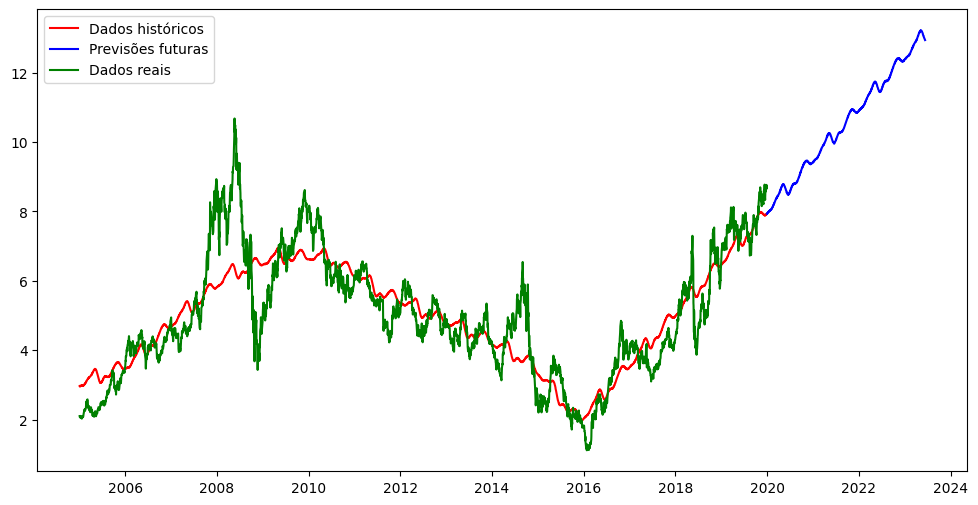

In [12]:

plt.figure(figsize=(12, 6))
plt.plot(
    previsoes_historicas["ds"],
    previsoes_historicas["yhat1"],
    label="Dados históricos",
    c="r",
)
plt.plot(
    previsoes_futuras["ds"],
    previsoes_futuras["yhat1"],
    label="Previsões futuras",
    c="b",
)

plt.plot(data["ds"], data["y"], label="Dados reais", c="g")
plt.legend()
plt.show()

In [13]:
# R2 avalia o quanto a variância dos dados é explicada no modelo
r2_score(y_true=previsoes_historicas["y"], y_pred=previsoes_historicas["yhat1"])

# O MAE mede a média do quanto seu modelo erra
mean_absolute_error(y_true=previsoes_historicas["y"], y_pred=previsoes_historicas["yhat1"])
mean_absolute_percentage_error(y_true=previsoes_historicas["y"], y_pred=previsoes_historicas["yhat1"])

0.13831098930253716